# Assignment 02 – Application 3: E-commerce Customer Preference Prediction

Binary classification of a review as **Positive Preference** (Score 4–5) or **Negative Preference** (Score 1–2). Score 3 is excluded. `Score`, target-derived values, and identifiers are never model inputs.

## 1. Problem Definition and Dataset Source

One observation is one customer's review of one product. Source: [Kaggle – Amazon Fine Food Reviews](https://www.kaggle.com/datasets/arhamrumi/amazon-product-reviews). The actual local file, not an expected schema, is the source of truth.

In [1]:
from pathlib import Path
import json, joblib, pandas as pd, numpy as np, sys
from IPython.display import display, Image
root = Path.cwd()
if not (root / 'data').exists(): root = root.parent.parent
if str(root) not in sys.path: sys.path.insert(0, str(root))
data_path = root / 'data/ecommerce/Reviews.csv'
results = json.loads((root / 'models/ecommerce/training_results.json').read_text(encoding='utf-8'))
df = pd.read_csv(data_path)
print('filename:', data_path.name, 'shape:', df.shape)
display(df.head())
df.info()
display(df.describe(include='all').transpose())

filename: Reviews.csv shape: (568454, 10)


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


<class 'pandas.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   Id                      568454 non-null  int64
 1   ProductId               568454 non-null  str  
 2   UserId                  568454 non-null  str  
 3   ProfileName             568428 non-null  str  
 4   HelpfulnessNumerator    568454 non-null  int64
 5   HelpfulnessDenominator  568454 non-null  int64
 6   Score                   568454 non-null  int64
 7   Time                    568454 non-null  int64
 8   Summary                 568427 non-null  str  
 9   Text                    568454 non-null  str  
dtypes: int64(5), str(5)
memory usage: 43.4 MB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Id,568454.0,NaN,NaN,NaN,284227.5,164098.679298,1.0,142114.25,284227.5,426340.75,568454.0
ProductId,568454,74258,B007JFMH8M,913,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UserId,568454,256059,A3OXHLG6DIBRW8,448,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ProfileName,568428,218415,"C. F. Hill ""CFH""",451,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HelpfulnessNumerator,568454.0,NaN,NaN,NaN,1.743817,7.636513,0.0,0.0,0.0,2.0,866.0
HelpfulnessDenominator,568454.0,NaN,NaN,NaN,2.22881,8.28974,0.0,0.0,1.0,2.0,923.0
Score,568454.0,NaN,NaN,NaN,4.183199,1.310436,1.0,4.0,5.0,5.0,5.0
Time,568454.0,NaN,NaN,NaN,1296256604.90242,48043312.332416,939340800.0,1271289600.0,1311120000.0,1332720000.0,1351209600.0
Summary,568427,295742,Delicious!,2462,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Text,568454,393579,"This review will make me sound really stupid, ...",199,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Inspection, Data Quality, Missing Values, Duplicates, Invalid Values, and Outliers

Missing summaries are retained and represented as empty strings because the review body is present. Blank text, invalid helpfulness relations, and exact duplicate review records are removed before splitting. Long reviews are retained—clipping is visualization-only—because their language carries signal.

In [2]:
print('Missing values:\n', df.isna().sum())
print('Full-row duplicates:', df.duplicated().sum())
print('Duplicate review keys:', df.duplicated(subset=['ProductId','UserId','Score','Summary','Text']).sum())
print('Score distribution:\n', df.Score.value_counts().sort_index())
print('Cleaning ledger:', results['dataset'])

Missing values:
 Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64


Full-row duplicates: 0


Duplicate review keys: 892
Score distribution:
 Score
1     52268
2     29769
3     42640
4     80655
5    363122
Name: count, dtype: int64
Cleaning ledger: {'raw_rows': 568454, 'target_valid_rows': 568454, 'neutral_removed': 42640, 'blank_text_removed': 0, 'invalid_helpfulness_removed': 2, 'duplicate_reviews_removed': 829, 'usable_rows': 524983, 'modeling_rows': 120000, 'modeling_distribution': {'0': 18686, '1': 101314}}


## 3. Feature Types and Target Analysis

Numerical: helpfulness numerator/denominator. Text: Summary/Text. Identifiers: Id/ProductId/UserId/ProfileName (excluded). Time is unused. Target comes only from Score, after which Score is excluded from X. This avoids target and identifier leakage.

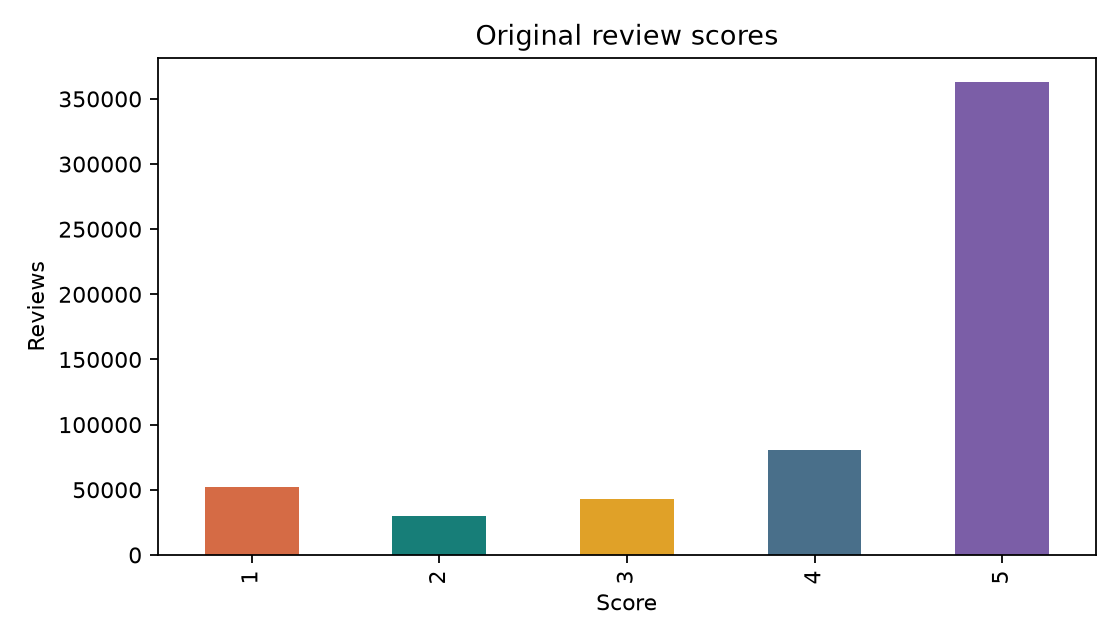

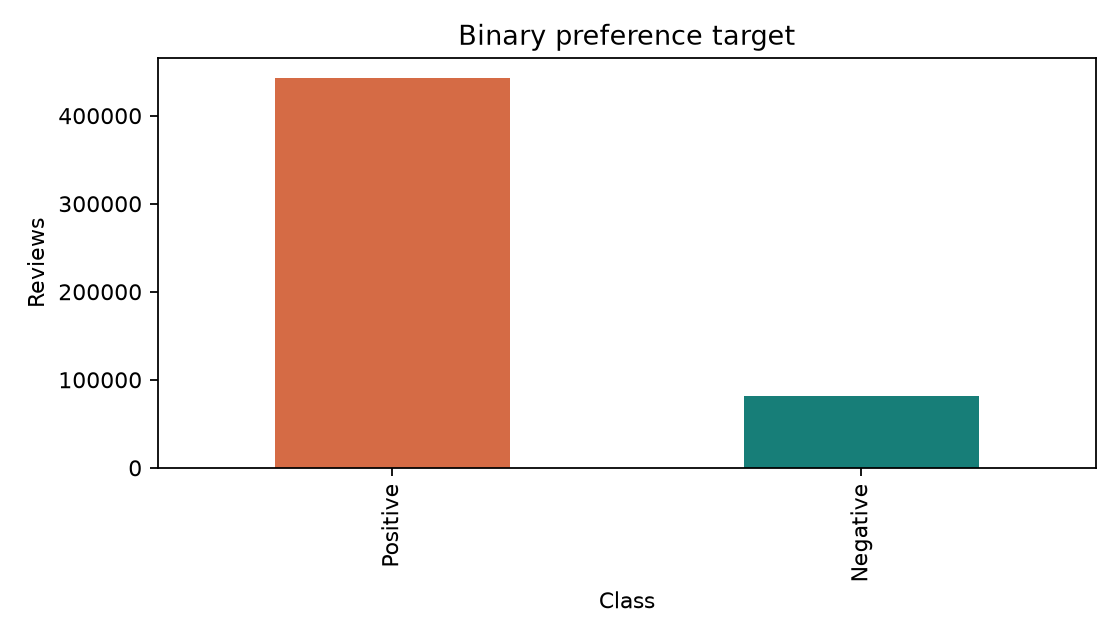

Modeling distribution: {'0': 18686, '1': 101314}


In [3]:
display(Image(filename=str(root/'figures/ecommerce/score_distribution.png')))
display(Image(filename=str(root/'figures/ecommerce/target_distribution.png')))
print('Modeling distribution:', results['dataset']['modeling_distribution'])

## 4. Cleaning and Reproducible Large-Dataset Strategy

The cleaning ledger reports raw → target-valid → neutral removal → invalid/duplicate removal → usable rows. A stratified 120,000-row sample (`random_state=42`) makes controlled sparse-model comparison feasible without claiming the source dataset has only 120,000 rows.

In [4]:
print(json.dumps(results['dataset'], indent=2)); print('70/15/15 splits:', results['splits'])

{
  "raw_rows": 568454,
  "target_valid_rows": 568454,
  "neutral_removed": 42640,
  "blank_text_removed": 0,
  "invalid_helpfulness_removed": 2,
  "duplicate_reviews_removed": 829,
  "usable_rows": 524983,
  "modeling_rows": 120000,
  "modeling_distribution": {
    "0": 18686,
    "1": 101314
  }
}
70/15/15 splits: {'train': 84000, 'validation': 18000, 'test': 18000}


## 5. EDA: Length, Helpfulness, and Textual Terms

**Observation:** positive reviews dominate; lengths have a long tail; helpfulness is concentrated near zero/no votes; coefficient terms differ by class. **Interpretation:** accuracy alone is insufficient and text contains sentiment signal. **ML implication:** stratification, F1/ROC-AUC, sparse TF-IDF, and a controlled tabular/text comparison are required.

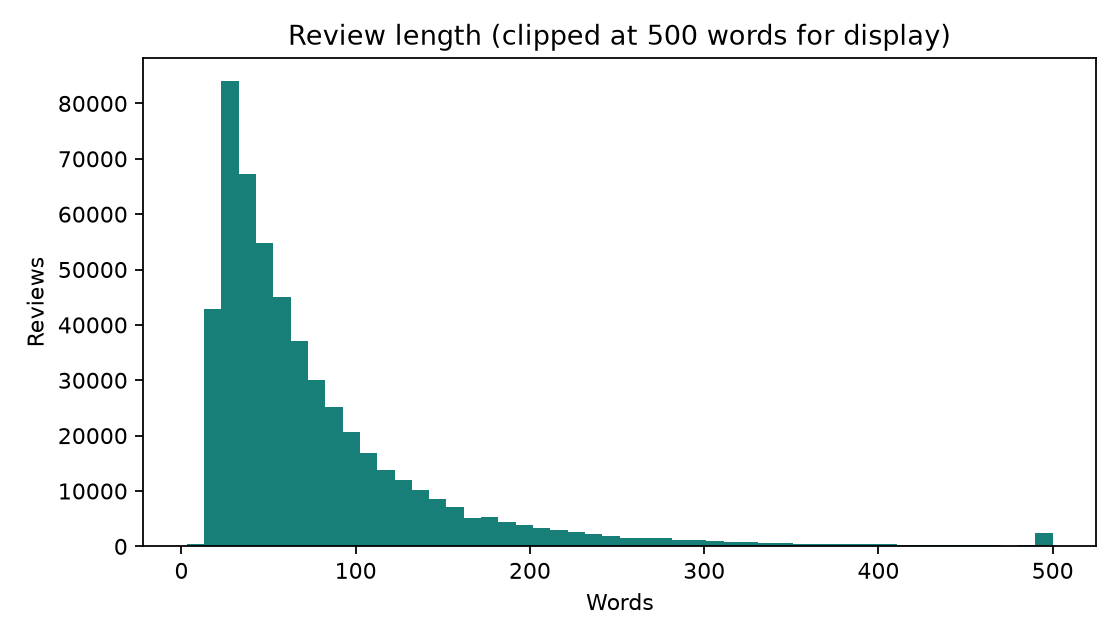

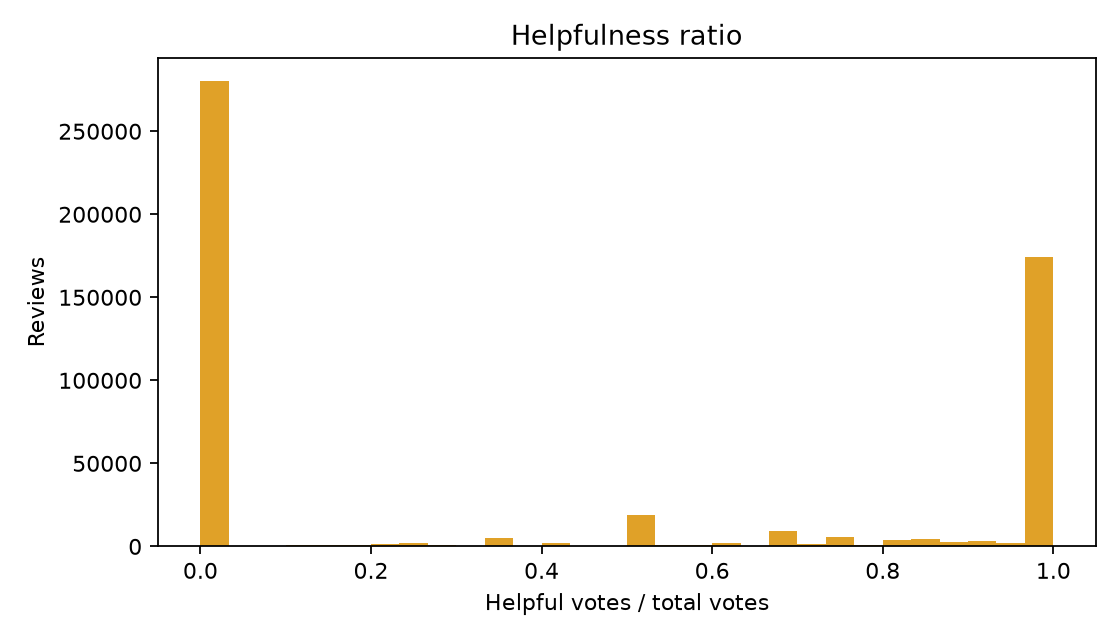

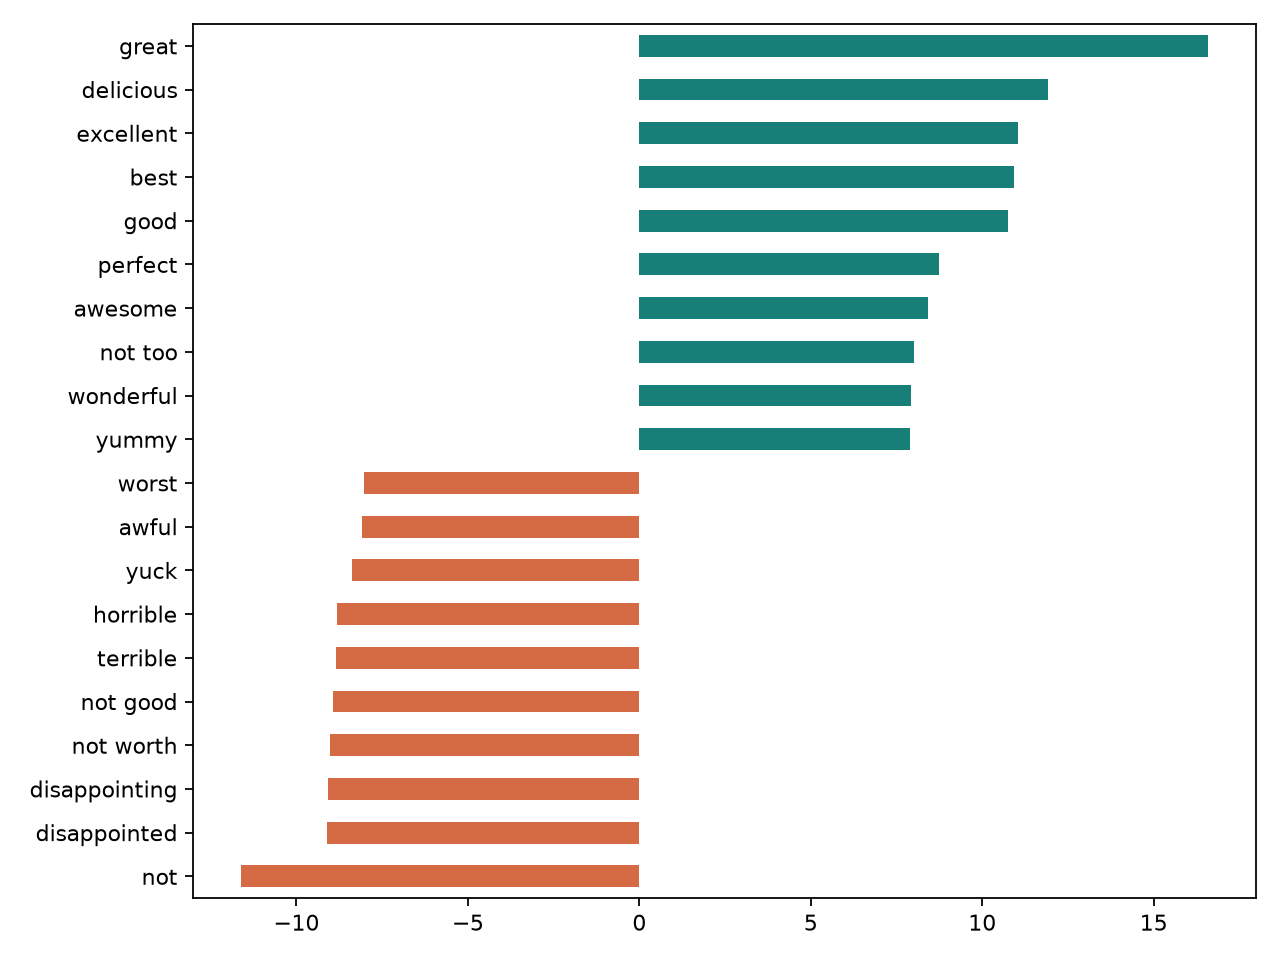

In [5]:
for name in ['review_length_distribution.png','helpfulness_distribution.png','top_terms.png']:
    display(Image(filename=str(root/'figures/ecommerce'/name)))

## 6. Raw → Tokens → Vocabulary IDs → TF-IDF → Sparse Matrix

For classical ML, the deployed representation is $X_{text} \in R^{B \times V}$ rather than a dense Transformer tensor $B \times T \times d$. Conceptually, $T$ is sequence length and $d$ an embedding width; neither is materialized here. TF-IDF preserves weighted lexical/ngram evidence but loses exact word order beyond bigrams and much context.

In [6]:
example = results['representation_example']
print('Original real review:', example['original'])
print('Tokens:', example['tokens'])
print('Real token → fitted vocabulary ID:', example['token_ids'])
print('Non-zero TF-IDF entries:', example['nonzero_tfidf'])
print('B = batch samples; V =', results['vocabulary_size'], '; d_tabular =', results['tabular_dimension'])
print('Final shape: B ×', results['final_transformed_dimension'])

Original real review: {'Summary': 'Yummy and Fast!', 'Text': "This is a high quality scone mix. I love scones, and I never seem to have time to make them. I don't like scones in most bakeries (ugh, Starbucks, I'm looking at you!), and these are a life saver whenever I want a scone with tea. I love scones so much I actually named my cat Scone. I've also substituted the water with milk and cream, and it has come out delicious each time. I like to have a few on hand for company. The scones also freeze well.", 'HelpfulnessNumerator': 0, 'HelpfulnessDenominator': 0}
Tokens: ['yummy', 'and', 'fast', 'this', 'is', 'high', 'quality', 'scone', 'mix', 'love', 'scones', 'and', 'never', 'seem', 'to', 'have', 'time', 'to', 'make', 'them']
Real token → fitted vocabulary ID: {'yummy': 11989, 'and': 433, 'fast': 3407, 'this': 10245, 'is': 5069, 'high': 4687, 'quality': 7905, 'mix': 6278, 'love': 5942, 'never': 6579, 'seem': 8398, 'to': 10472, 'have': 4482, 'time': 10427, 'make': 6024, 'them': 10004}
N

## 7. Engineered Tabular Representation

Five values are produced consistently inside the persisted transformer: helpfulness numerator, denominator, ratio, review word count, and summary word count. The ratio uses denominator `max(value, 1)`.

## 8. Train / Validation / Test and Leakage Audit

70% train fits vocabulary/models, 15% validation selects representation/model, and 15% test is used once after freezing. Exact duplicates are removed first. Score creates y only; identifiers, Score and target never enter X. The final artifact refits the frozen configuration on train+validation and evaluates test once.

In [7]:
print(results['splits']); print('Raw model fields:', results['raw_fields'])

{'train': 84000, 'validation': 18000, 'test': 18000}
Raw model fields: ['Summary', 'Text', 'HelpfulnessNumerator', 'HelpfulnessDenominator']


## 9. Baseline

A majority-positive DummyClassifier predicts every validation sample positive: this gives high-looking accuracy/recall because of imbalance, but zero negative recall. F1 and ROC-AUC provide necessary context.

In [8]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from scripts.train_ecommerce import clean_data, RAW_FIELDS
usable_for_baseline, _ = clean_data(df)
modeling_for_baseline, _ = train_test_split(usable_for_baseline, train_size=120000, stratify=usable_for_baseline.target, random_state=42)
train_for_baseline, holdout_for_baseline = train_test_split(modeling_for_baseline, test_size=.30, stratify=modeling_for_baseline.target, random_state=42)
validation_for_baseline, _ = train_test_split(holdout_for_baseline, test_size=.50, stratify=holdout_for_baseline.target, random_state=42)
dummy = DummyClassifier(strategy='most_frequent').fit(train_for_baseline[RAW_FIELDS], train_for_baseline.target)
dummy_pred = dummy.predict(validation_for_baseline[RAW_FIELDS])
print({'accuracy':accuracy_score(validation_for_baseline.target,dummy_pred),'precision':precision_score(validation_for_baseline.target,dummy_pred),'recall':recall_score(validation_for_baseline.target,dummy_pred),'f1':f1_score(validation_for_baseline.target,dummy_pred)})

{'accuracy': 0.8442777777777778, 'precision': 0.8442777777777778, 'recall': 1.0, 'f1': 0.9155646594571799}


## 10. Controlled Representation Experiment (Fixed Logistic Regression)

Same rows, split, target, classifier, random state and evaluation; only representation changes.

,accuracy,precision,recall,f1,roc_auc,training_time_seconds
A_tabular_only,0.844167,0.844528,0.999408,0.915464,0.640997,0.24
B_text_only,0.957000,0.962721,0.987300,0.974855,0.983600,2.25
C_tabular_plus_text,0.957444,0.963096,0.987432,0.975112,0.984033,3.25


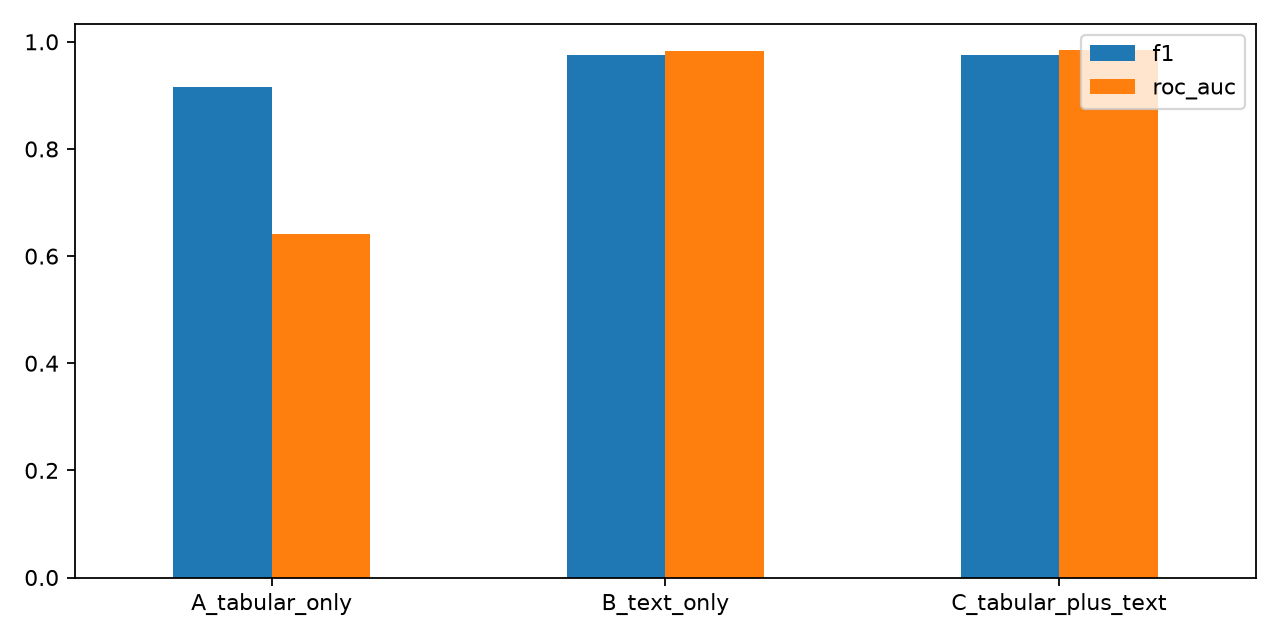

In [9]:
display(pd.DataFrame(results['representation_results']).T); display(Image(filename=str(root/'figures/ecommerce/representation_comparison.png')))

**Conclusion:** text produces a large evidence-backed improvement over tabular-only representation; adding the five tabular features gives a small further validation gain.

## 11. Six-Model Validation Comparison and Training Time

All models consume the same sparse combined matrix. Linear SVC has the highest F1 but no native probability. Logistic Regression is within 0.01 F1, has the highest compared ROC-AUC, returns a calibrated-style probabilistic output directly, and is simple to deploy; the predeclared selection rule therefore chooses it.

,accuracy,precision,recall,f1,roc_auc,training_time_seconds
Linear SVC,0.959833,0.970302,0.982497,0.976361,0.983159,3.16
Logistic Regression,0.957444,0.963096,0.987432,0.975112,0.984033,3.48
SGD Classifier,0.953056,0.956489,0.989406,0.972669,0.982840,0.55
Decision Tree,0.898889,0.922975,0.960387,0.941309,0.856828,47.38
Complement NB,0.903111,0.984723,0.899191,0.940015,0.970737,0.05
Random Forest,0.858778,0.856700,1.000000,0.922820,0.951243,5.56


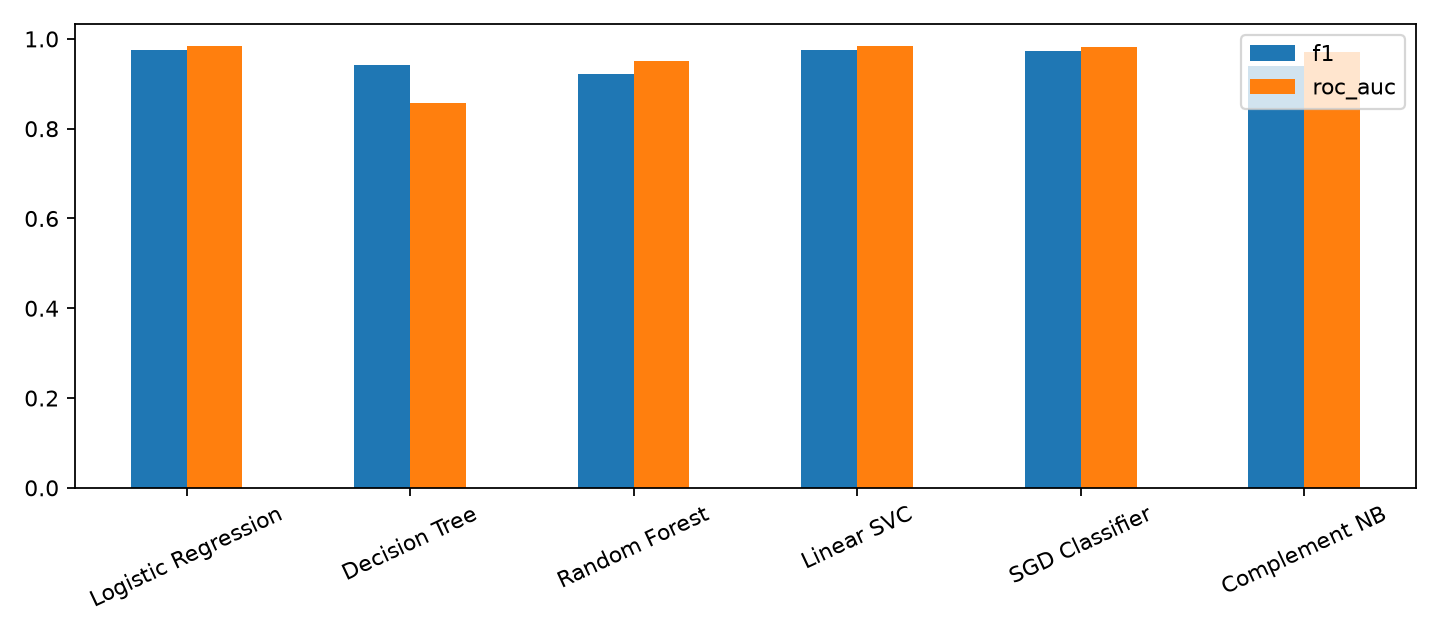

Highest validation F1 among probability-capable models within 0.01 of the overall best F1; ROC-AUC breaks ties.


In [10]:
display(pd.DataFrame(results['model_comparison']).T.sort_values('f1', ascending=False)); display(Image(filename=str(root/'figures/ecommerce/model_comparison.png'))); print(results['selection_rule'])

## 12. Final Model, One-Time Test Evaluation, Confusion Matrix, ROC, and Error Analysis

Selected: Logistic Regression
{
  "accuracy": 0.9565555555555556,
  "precision": 0.9638926433674454,
  "recall": 0.9854576561163387,
  "f1": 0.9745558664671048,
  "roc_auc": 0.9842295939185286,
  "training_time_seconds": 22.82,
  "confusion_matrix": [
    [
      2242,
      561
    ],
    [
      221,
      14976
    ]
  ],
  "classification_report": {
    "0": {
      "precision": 0.9102720259845717,
      "recall": 0.7998572957545487,
      "f1-score": 0.8515001898974554,
      "support": 2803.0
    },
    "1": {
      "precision": 0.9638926433674454,
      "recall": 0.9854576561163387,
      "f1-score": 0.9745558664671048,
      "support": 15197.0
    },
    "accuracy": 0.9565555555555556,
    "macro avg": {
      "precision": 0.9370823346760085,
      "recall": 0.8926574759354438,
      "f1-score": 0.91302802818228,
      "support": 18000.0
    },
    "weighted avg": {
      "precision": 0.9555427216716568,
      "recall": 0.9565555555555556,
      "f1-score": 0.9553933630546199,


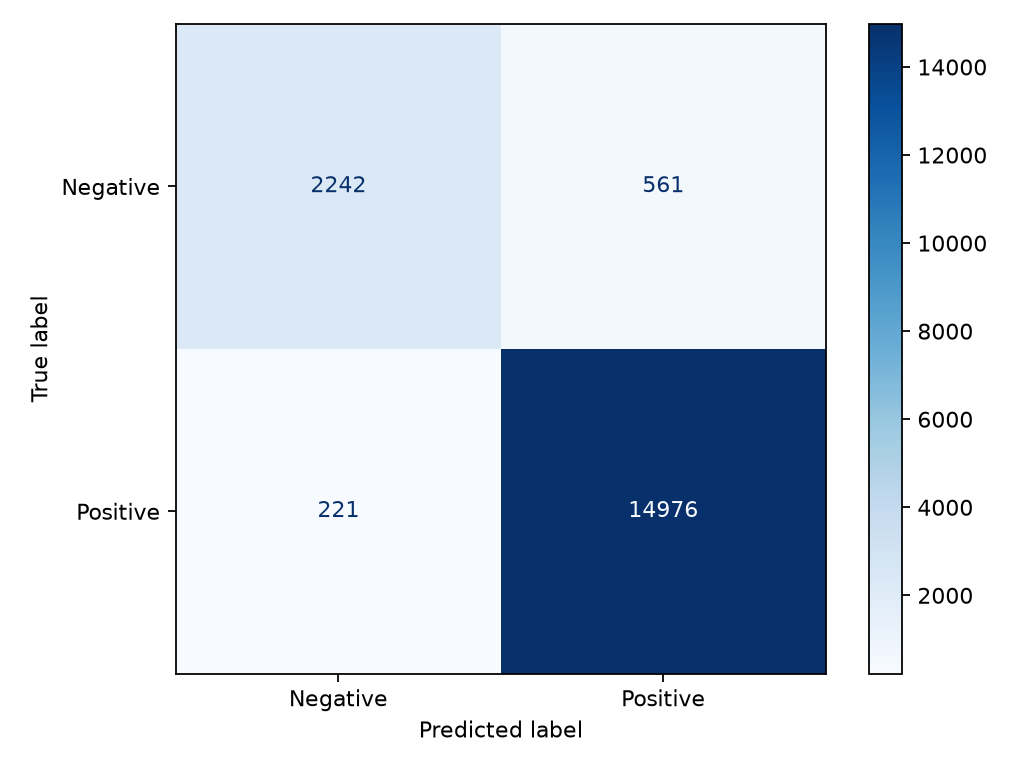

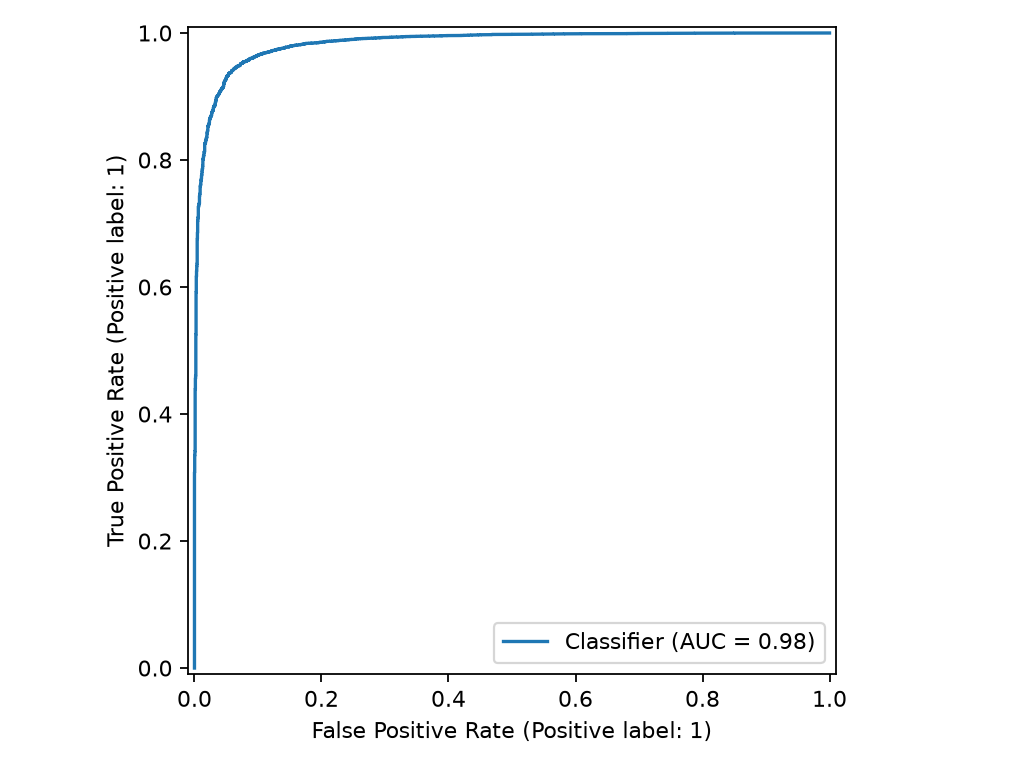

,Summary,Text,Score,target,prediction
0,Pleases picky cat!...for awhile.,My picky cat loves these so although they seem...,2,0,1
1,Bit of an aftertaste,I can taste the sugar substitute in this quite...,4,1,0
2,What A Bad Trip!,I downed a bottle of this in about two minutes...,2,0,1
3,PUMPKIN SPICE K-CUPS,I was disappointed in this purchase. Both my h...,5,1,0
4,Not very thick,This honey is very similar to regular clover h...,2,0,1
5,"Annie Chun's Noodle Bowl Teriyaki - Pain, muc...",I had this for the first time today and I am i...,1,0,1
6,great product but extremely overpriced,I LOVE the product and was hoping to buy it bu...,5,1,0
7,My buddy loved it until he threw it all back u...,"my havanese absolutely loved this, but he spen...",1,0,1


In [11]:
print('Selected:', results['selected_model']); print(json.dumps(results['test_metrics'], indent=2));
display(Image(filename=str(root/'figures/ecommerce/confusion_matrix.png'))); display(Image(filename=str(root/'figures/ecommerce/roc_curve.png')))
errors = pd.read_csv(root/'models/ecommerce/error_examples.csv'); display(errors[['Summary','Text','Score','target','prediction']].head(8))

False positives and false negatives above are inspected directly. Short, generic, or mixed-sentiment wording is discussed only where visible in these actual examples; rating/text disagreement is a limitation of the rating-derived target.

## 13. Persistence and Fresh-Load Inference

The joblib file contains the fitted text transformer/vectorizer, engineered tabular transformer/scaler, and classifier. Transformer classes live in importable `shared_ml`, never notebook-local lambdas/classes.

In [12]:
artifact=root/'models/ecommerce/ecommerce_interest_model.joblib'; pipeline=joblib.load(artifact)
demo=pd.DataFrame([{'Summary':'Excellent','Text':'Fresh, tasty and exactly as described. I would buy it again.','HelpfulnessNumerator':1,'HelpfulnessDenominator':1},{'Summary':'Disappointed','Text':'Stale product, damaged package and a complete waste of money.','HelpfulnessNumerator':0,'HelpfulnessDenominator':1},{'Summary':'Okay','Text':'The taste is acceptable but the price is high for the size.','HelpfulnessNumerator':0,'HelpfulnessDenominator':0}])
print('feature_names_in_:', list(pipeline.feature_names_in_)); print('predictions:', pipeline.predict(demo)); print('positive probabilities:', pipeline.predict_proba(demo)[:,1]); print('saved reload equality:', results['reload_predictions_equal'])

feature_names_in_: ['Summary', 'Text', 'HelpfulnessNumerator', 'HelpfulnessDenominator']
predictions: [1 0 0]
positive probabilities: [9.99820099e-01 3.61314252e-04 3.35031191e-01]
saved reload equality: True


## 14. Deployment Contract and Limitations

FastAPI accepts exactly Summary, Text, HelpfulnessNumerator and HelpfulnessDenominator and calls only the saved Pipeline. Web and mobile send raw values over REST. The task predicts a rating-derived preference proxy, not actual intention; positive imbalance and possible near-duplicate/user/product dependencies limit generalization.